In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load CSV (adjust path as needed)
#df = pd.read_csv("../eval_results/eval_20260504_121229_reduced.csv") # results 1 old
#df = pd.read_csv("../eval_results/eval_20260509_112934_reduced.csv") # results 2 old
#df = pd.read_csv("../eval_results/eval_20260509_123731_reduced_combined.csv") # results 3 old

#df = pd.read_csv("../eval_results/eval_20260510_112617_reduced.csv") # random seed

#df = pd.read_csv("../eval_results/eval_20260510_125711_reduced.csv") # seed 42
#df = pd.read_csv("../eval_results/eval_20260510_140530_reduced.csv") # seed 43
df = pd.read_csv("../eval_results/eval_20260516_122253_reduced.csv") # seed 44


# Convert numeric columns (empty strings -> NaN automatically handled)
numeric_cols = [
    "response_time",
    "faithfulness",
    "context_precision",
    "constraint_satisfaction",
    "hallucination_rate"
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

In [3]:
# Group by system and compute mean + variance
grouped = df.groupby("system")[numeric_cols].agg(["mean", "var"])

print(grouped)

             response_time           faithfulness           context_precision  \
                      mean       var         mean       var              mean   
system                                                                          
llm               2.296051  0.563673          NaN       NaN               NaN   
rag_hybrid        2.516107  0.593452     0.918504  0.056806             0.452   
rag_standard      2.427064  0.342506     0.877405  0.077948             0.392   

                       constraint_satisfaction           hallucination_rate  \
                   var                    mean       var               mean   
system                                                                        
llm                NaN                0.989833  0.002020           0.031425   
rag_hybrid    0.103127                0.964000  0.011654                NaN   
rag_standard  0.084784                0.963000  0.010020                NaN   

                        
             

In [4]:
# Assign group IDs (each 3 rows = 1 group)
df["group_id"] = df.index // 3

# Keep only hybrid and standard
subset = df[df["system"].isin(["rag_hybrid", "rag_standard"])]

# Pivot within each group
pivot = subset.pivot(index="group_id", columns="system", values=numeric_cols)

# Split hybrid and standard
hybrid = pivot.xs("rag_hybrid", level=1, axis=1)
standard = pivot.xs("rag_standard", level=1, axis=1)

# Initialize comparison dataframe
comparison = pd.DataFrame(index=hybrid.index, columns=hybrid.columns)

# Metrics where higher is better
higher_is_better = [col for col in numeric_cols if col not in ["response_time", "hallucination_rate"]]

# Higher is better
comparison[higher_is_better] = (hybrid[higher_is_better] > standard[higher_is_better]).astype(int) - \
                              (hybrid[higher_is_better] < standard[higher_is_better]).astype(int)

# Lower is better
lower_is_better = ["response_time", "hallucination_rate"]

comparison[lower_is_better] = (hybrid[lower_is_better] < standard[lower_is_better]).astype(int) - \
                             (hybrid[lower_is_better] > standard[lower_is_better]).astype(int)

# Now count outcomes
better = (comparison == 1).sum()
equal = (comparison == 0).sum()
worse = (comparison == -1).sum()

total = comparison.count()

# Rates
better_rate = better / total
equal_rate = equal / total
worse_rate = worse / total

print("Better:\n", better)
print("\nEqual:\n", equal)
print("\nWorse:\n", worse)

Better:
 response_time              43
faithfulness               20
context_precision          39
constraint_satisfaction    11
hallucination_rate          0
dtype: int64

Equal:
 response_time                0
faithfulness                67
context_precision           34
constraint_satisfaction     78
hallucination_rate         100
dtype: int64

Worse:
 response_time              57
faithfulness               13
context_precision          27
constraint_satisfaction    11
hallucination_rate          0
dtype: int64


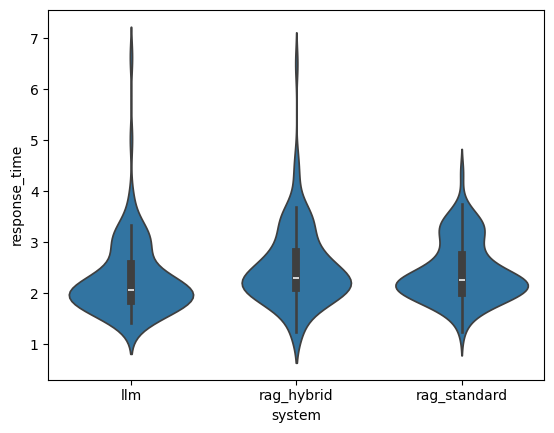

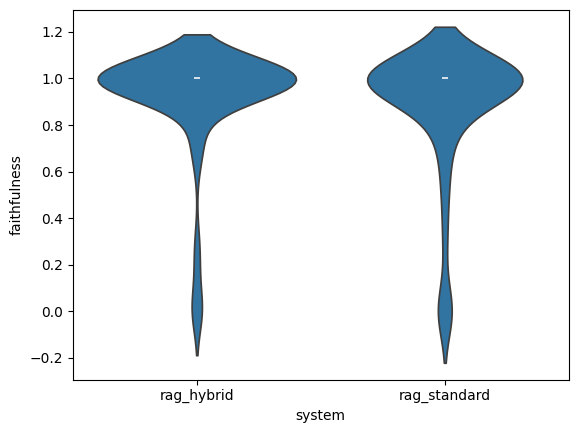

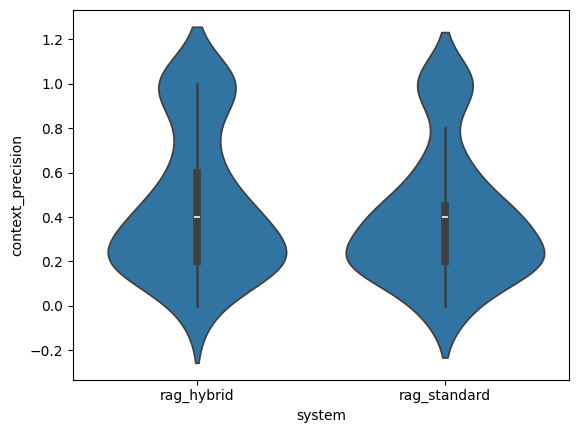

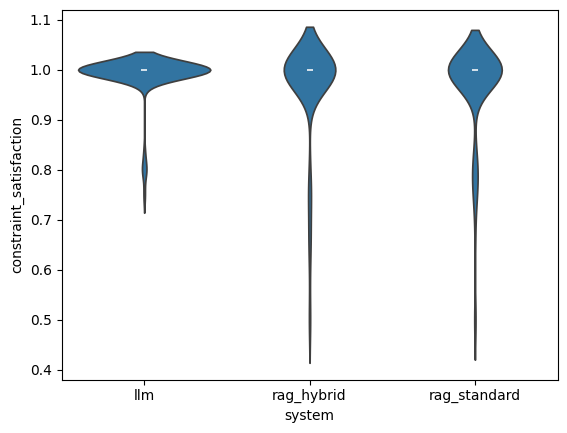

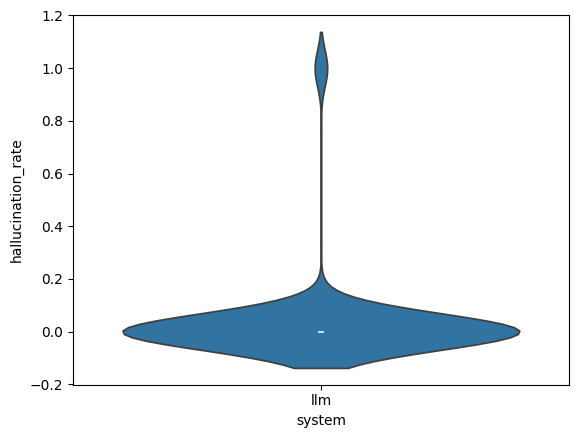

In [5]:
for col in numeric_cols:
    sub = df[["system", col]].dropna()

    # skip if nothing left after removing missing values
    if sub.empty:
        continue

    sns.violinplot(data=sub, x="system", y=col)
    plt.show()